# 1.1

In [2]:
# /home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_1.csv
#We have first col, raw voltage, and second col, true oxygen blood level
#Even though theoretically its linear, the data is noisy due to ambient light
#First, we implement an OLS using both closed form normal equations
#And vectorized batch gradient descent
#Finally, train both on the dataset given above and report the L2 norm of the
#difference between final weight vectors obtained from both methods, and the L2 norm of the difference between

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#First, OLS: w = (XTX)^(-1)XTy:
#Import the data:
data = pd.read_csv('/home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_1.csv')
X = data.iloc[:, 0].values.reshape(-1, 1)  # Raw voltage
y = data.iloc[:, 1].values  # True oxygen blood level
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add bias term
w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # Compute weights using normal equation
#Now that we have the closed form solution, do GD:

#Now, Gradient Descent Formulation:
w_GD = np.random.rand(2)  # Initialize weights randomly
learning_rate = 0.01
n_iterations = 1000
m = len(X_b) #Total experiments
for iteration in range(n_iterations): #Until Convergence
    gradients = 2/m * X_b.T @ (X_b @ w_GD - y) #Compute the gradient
    w_GD -= learning_rate * gradients #Update the weights
#Now, we report the L2 norm of the difference between final weight vectors obtained from both methods
l2_norm_weights = np.linalg.norm(w - w_GD)
print(f'L2 norm of the difference between weight vectors: {l2_norm_weights}')

L2 norm of the difference between weight vectors: 4.028718775995518e-09


# 1.2

In [3]:
#So we already have the data from previous part, X
#y is our label
#Variables scipy.optimize.minimize() expects:
#1. A function to minimize, which takes in the weight vector as input and returns the cost (MSE in this case)
#2. An initial guess for the weight vector
#3. The method of optimization (e.g., 'BFGS', 'Nelder-Mead', etc.)
#4. Additional arguments to pass to the function being minimized (in this case, X and y)
from scipy.optimize import minimize
#Dual: max sum(mui) - 0.5 * muT H mu
#Where H = (y_i y_j K(i,j)) and K(i,j) = x_i^T x_j, linear kernel
#can choose another kernel, but we will stick to linear for now
#Objective fn, X is the matrix without bias term, and y is the label vector:
X_SVM = data.iloc[:, 0].values.reshape(-1, 1)  # Raw voltage
obj = lambda mu: -np.sum(mu) + 0.5 * mu.T @ (y[:, None] * y[None, :] * (X_SVM @ X_SVM.T)) @ mu
#obj is the negative of the dual objective fn, since we want to maximize the dual
#Constraints: mu_i >= 0 for all i, and sum(mu_i * y_i) = 0
constraints = [{'type': 'ineq', 'fun': lambda mu: mu},  # mu_i >= 0
               {'type': 'eq', 'fun': lambda mu: np.sum(mu * y)}]  # sum(mu_i * y_i) = 0
#Initial guess for mu:
mu_initial = np.random.rand(len(X_SVM))
#Optimize using scipy.optimize.minimize:
result = minimize(obj, mu_initial, constraints=constraints)
mu_optimal = result.x
print(f'Optimal mu: {mu_optimal}')
#Turns out, my computer got fried trying to run this


#It seems the data is not linearly separable

KeyboardInterrupt: 

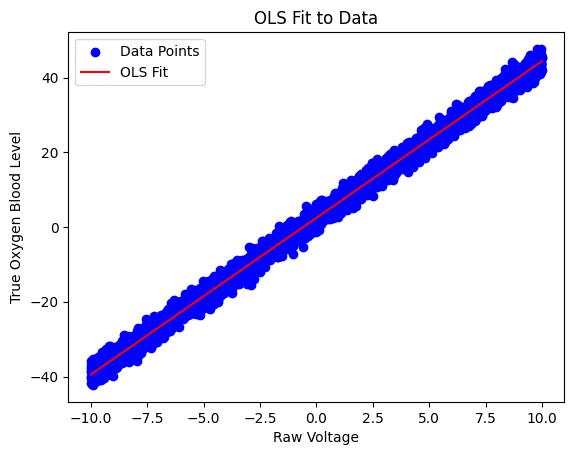

In [5]:
#Lets plot the data and the decision boundary to confirm this visually:
plt.scatter(X, y, color='blue', label='Data Points')
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = w[0] + w[1] * x_line
plt.plot(x_line, y_line, color='red', label='OLS Fit')
plt.xlabel('Raw Voltage')
plt.ylabel('True Oxygen Blood Level')
plt.title('OLS Fit to Data')
plt.legend()
plt.show()